Importing Required Libraries

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Load dataset

In [195]:
df=pd.read_csv("/content/Titanic-Dataset.csv")

Explore Data

In [196]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [197]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


Handle missing values

In [198]:
# Fill missing Age values with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Fill missing Embarked values with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column
df = df.drop('Cabin', axis=1)

# Check again
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Encoding

In [199]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket     Fare  Embarked  
0         A/5 21171   7.2500         2  
1          PC 17599  71.2833         0  
2  STON/O2. 3101282   7.9250         2  
3            113803  53.1000         2  
4            373450   8.0500         2  


Exploratory Data Analysis

•survival count

In [200]:
df['Survived'].value_counts()
df['Survived'].mean()*100

np.float64(38.38383838383838)

<Axes: xlabel='Survived', ylabel='count'>

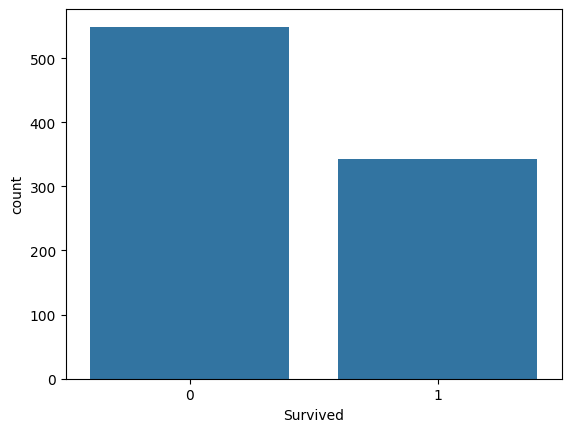

In [201]:
sns.countplot(x='Survived', data=df)

•sex vs survival

In [202]:
df.groupby('Sex')['Survived'].mean() * 100

,Survived
Sex,
0,74.203822
1,18.890815


<Axes: xlabel='Sex', ylabel='count'>

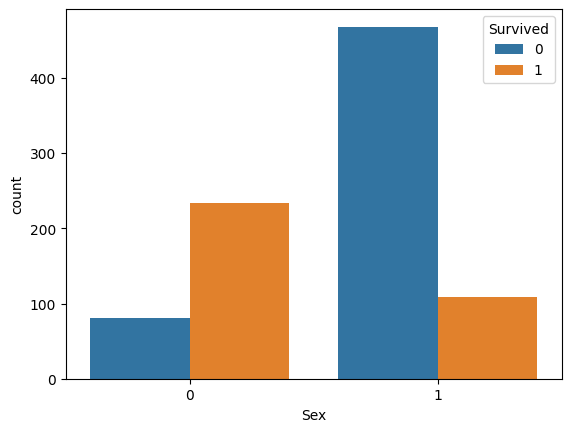

In [203]:
sns.countplot(x='Sex', hue='Survived', data=df)

•pclass vs survival

<Axes: xlabel='Pclass', ylabel='count'>

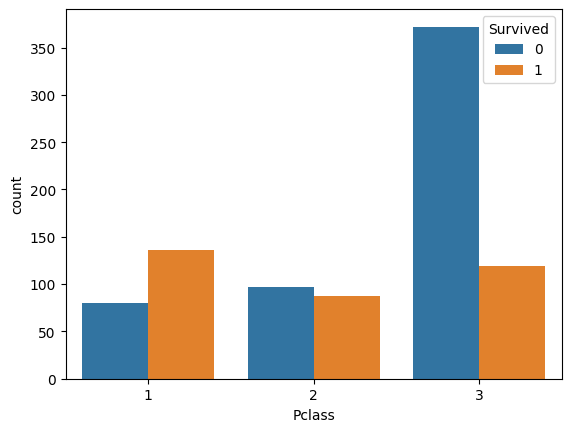

In [204]:
sns.countplot(x='Pclass', hue='Survived', data=df)

•age histogram

<Axes: xlabel='Age', ylabel='Count'>

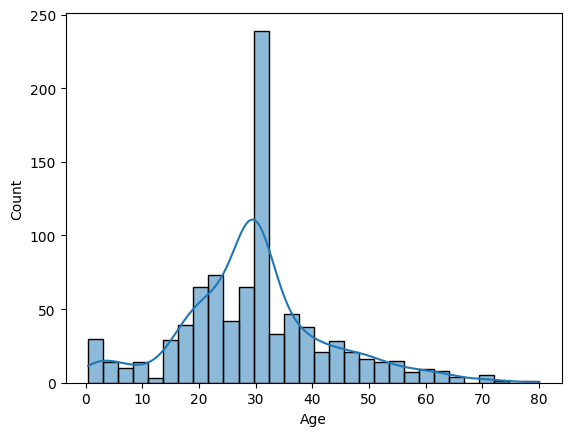

In [205]:
sns.histplot(df['Age'], bins=30, kde=True)

•fare distribution

<Axes: xlabel='Fare', ylabel='Count'>

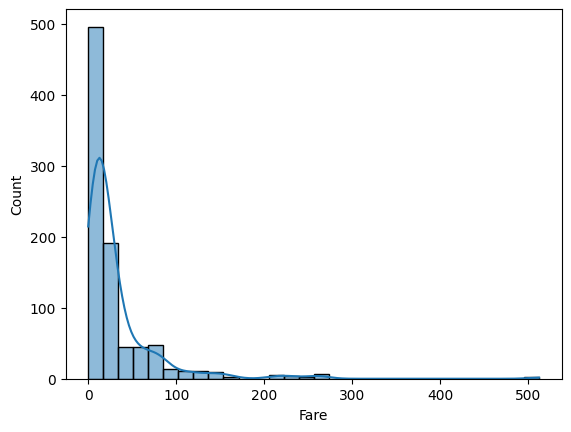

In [206]:
sns.histplot(df['Fare'], bins=30, kde=True)

Correlation heatmap

<Axes: >

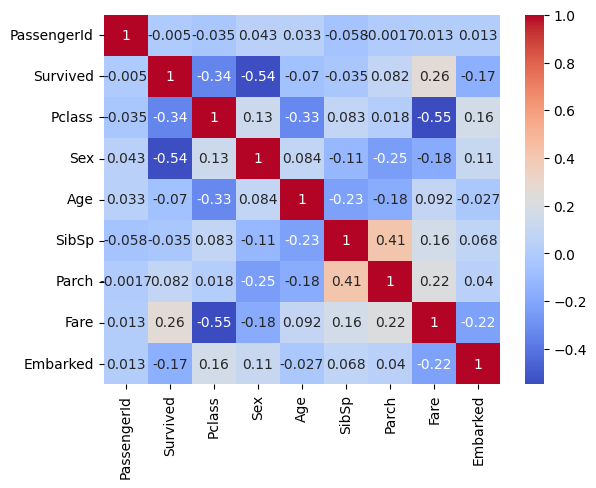

In [207]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

Data Engineering

In [208]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [209]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [210]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

le = LabelEncoder()
df['Title'] = le.fit_transform(df['Title'])

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_2903/790081418.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Classify X and Y

In [211]:
X = df[['Pclass', 'Sex', 'Age', 'Fare','SibSp','Parch','Embarked',
        'FamilySize','IsAlone','Title']]
y = df['Survived']

Train , Test & Split

In [212]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

Model building

In [213]:
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

Model fitting and Accuracy checking

In [214]:
from sklearn.metrics import accuracy_score

# Fit the model
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8044692737430168


Confusion matrics

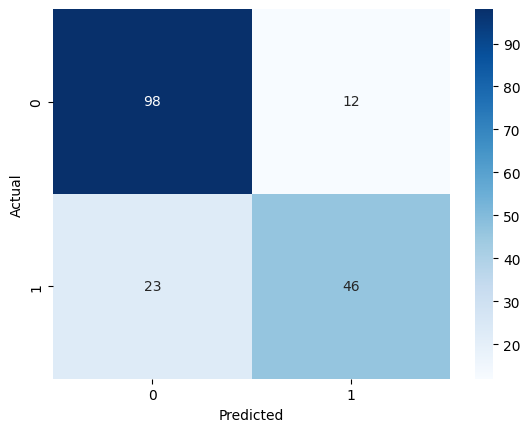

In [215]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report

In [216]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



Features Importance

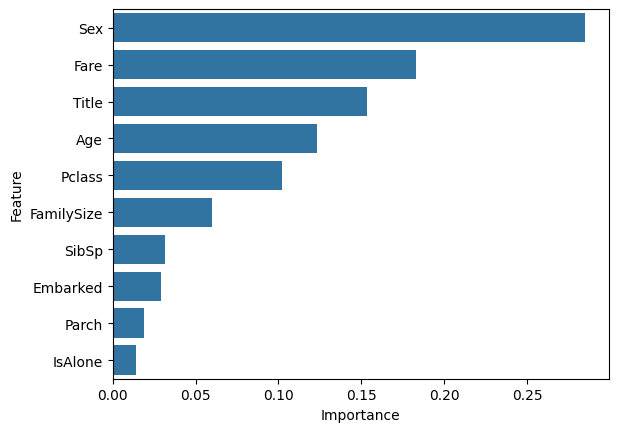

In [217]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.show()